## Configuración del entorno

Ejecute la siguiente celda para instalar las librerías necesarias para este Notebook. Si ya las tiene instaladas, la celda simplemente confirmará que están disponibles.

In [18]:
!pip install matplotlib
!pip install matplotlib seaborn
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 11.3 MB/s eta 0:00:000:00:01m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 11.5 MB/s eta 0:00:00m eta 0:00:010:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [scikit-learn]0m 4/5 [scikit-learn]


# Tarea 02: Manipulación y Procesamiento de Datos con Python
**Alumno:** Jesús Abel Vera Cruz
**Fecha:** 15 de julio de 2026
**Dataset:** train.csv  (misma carpeta para que pueda correr)

In [10]:
# Importación de librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date

# Configurar pandas para mostrar texto completo sin truncar
pd.set_option('display.max_colwidth', 60)   # Ancho máximo de columna en caracteres
pd.set_option('display.width', 120)         # Ancho total de la tabla en caracteres

# Guardar el CSV en la misma carpeta para que el evaluador pueda correrlo

# Cargar dataset (misma carpeta para que pueda correr)
df = pd.read_csv('train.csv')
# Mostrar información general del dataset
print("="*60)
print("Información general del dataset")
print("="*60)
print("Forma (filas, columnas)")
print("\n" + "="*60)
print("Tipos de datos por columna")
print("="*60)
print(df.dtypes)
print("\n" + "="*60)
print("Información detallada")
print("="*60)
df.info()
print("\n" + "="*60)
print("Variables nuemericas y categoricas")
print("="*60)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['string']).columns
print(f"Variables numéricas: {len(num_cols)}")
print(f"Variables categóricas: {len(cat_cols)}")
print(f"Total: {len(num_cols) + len(cat_cols)}")



Información general del dataset
Forma (filas, columnas)

Tipos de datos por columna
Id                 int64
MSSubClass         int64
MSZoning             str
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType             str
SaleCondition        str
SalePrice          int64
Length: 81, dtype: object

Información detallada
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utiliti

In [4]:
# Diccionario con la descripción de todas las variables del dataset Ames Housing
variable_description = {
    # Variable objetivo
    'SalePrice': 'Precio de venta de la propiedad en dólares (variable objetivo)',
    
    # Características generales
    'MSSubClass': 'Clase de construcción',
    'MSZoning': 'Clasificación general de zonificación',
    'LotFrontage': 'Pies lineales de calle conectados a la propiedad',
    'LotArea': 'Tamaño del lote en pies cuadrados',
    'Street': 'Tipo de acceso vial',
    'Alley': 'Tipo de acceso a callejón',
    'LotShape': 'Forma general de la propiedad',
    'LandContour': 'Planitud de la propiedad',
    'Utilities': 'Tipo de servicios públicos disponibles',
    'LotConfig': 'Configuración del lote',
    'LandSlope': 'Pendiente de la propiedad',
    'Neighborhood': 'Ubicaciones físicas dentro de los límites de la ciudad de Ames',
    'Condition1': 'Proximidad a carretera principal o ferrocarril',
    'Condition2': 'Proximidad a carretera principal o ferrocarril (si hay un segundo)',
    'BldgType': 'Tipo de vivienda',
    'HouseStyle': 'Estilo de vivienda',
    'OverallQual': 'Calidad general de materiales y acabados',
    'OverallCond': 'Calificación general de condición',
    'YearBuilt': 'Fecha de construcción original',
    'YearRemodAdd': 'Fecha de remodelación',
    'RoofStyle': 'Tipo de techo',
    'RoofMatl': 'Material del techo',
    'Exterior1st': 'Cubierta exterior de la casa',
    'Exterior2nd': 'Cubierta exterior de la casa (si hay más de un material)',
    'MasVnrType': 'Tipo de revestimiento de mampostería',
    'MasVnrArea': 'Área de revestimiento de mampostería en pies cuadrados',
    'ExterQual': 'Calidad del material exterior',
    'ExterCond': 'Condición actual del material en el exterior',
    'Foundation': 'Tipo de cimientos',
    
    # Características del sótano
    'BsmtQual': 'Altura del sótano',
    'BsmtCond': 'Condición general del sótano',
    'BsmtExposure': 'Paredes de sótano a nivel de jardín o salida',
    'BsmtFinType1': 'Calidad del área terminada del sótano',
    'BsmtFinSF1': 'Pies cuadrados terminados de tipo 1',
    'BsmtFinType2': 'Calidad de la segunda área terminada (si está presente)',
    'BsmtFinSF2': 'Pies cuadrados terminados de tipo 2',
    'BsmtUnfSF': 'Pies cuadrados sin terminar del área del sótano',
    'TotalBsmtSF': 'Pies cuadrados totales del área del sótano',
    'BsmtFullBath': 'Baños completos en el sótano',
    'BsmtHalfBath': 'Medios baños en el sótano',
    
    # Características de la vivienda
    'Heating': 'Tipo de calefacción',
    'HeatingQC': 'Calidad y condición de la calefacción',
    'CentralAir': 'Aire acondicionado central',
    'Electrical': 'Sistema eléctrico',
    '1stFlrSF': 'Pies cuadrados del primer piso',
    '2ndFlrSF': 'Pies cuadrados del segundo piso',
    'LowQualFinSF': 'Pies cuadrados terminados de baja calidad (todos los pisos)',
    'GrLivArea': 'Pies cuadrados de área habitable por encima del nivel del suelo',
    'FullBath': 'Baños completos por encima del nivel del suelo',
    'HalfBath': 'Medios baños por encima del nivel del suelo',
    'BedroomAbvGr': 'Número de dormitorios por encima del nivel del sótano',
    'Kitchen': 'Número de cocinas',
    'KitchenQual': 'Calidad de la cocina',
    'TotRmsAbvGrd': 'Total de habitaciones por encima del nivel del suelo (no incluye baños)',
    'Functional': 'Calificación de funcionalidad del hogar',
    'Fireplaces': 'Número de chimeneas',
    'FireplaceQu': 'Calidad de la chimenea',
    
    # Características del garaje
    'GarageType': 'Ubicación del garaje',
    'GarageYrBlt': 'Año en que se construyó el garaje',
    'GarageFinish': 'Acabado interior del garaje',
    'GarageCars': 'Capacidad del garaje en autos',
    'GarageArea': 'Tamaño del garaje en pies cuadrados',
    'GarageQual': 'Calidad del garaje',
    'GarageCond': 'Condición del garaje',
    
    # Características exteriores
    'PavedDrive': 'Entrada pavimentada',
    'WoodDeckSF': 'Área de terraza de madera en pies cuadrados',
    'OpenPorchSF': 'Área de porche abierto en pies cuadrados',
    'EnclosedPorch': 'Área de porche cerrado en pies cuadrados',
    '3SsnPorch': 'Área de porche de tres estaciones en pies cuadrados',
    'ScreenPorch': 'Área de porche con mosquitero en pies cuadrados',
    'PoolArea': 'Área de la piscina en pies cuadrados',
    'PoolQC': 'Calidad de la piscina',
    'Fence': 'Calidad de la cerca',
    'MiscFeature': 'Característica miscelánea no cubierta en otras categorías',
    'MiscVal': 'Valor en dólares de la característica miscelánea',
    
    # Características de venta
    'MoSold': 'Mes de venta',
    'YrSold': 'Año de venta',
    'SaleType': 'Tipo de venta',
    'SaleCondition': 'Condición de la venta'
}
desc_df = pd.DataFrame(list(variable_description.items()), columns=['Variable', 'Descripción'])
# Calcular porcentaje de nulos para cada variable
missing_pct = df.isnull().mean() * 100
desc_df['% Nulos'] = desc_df['Variable'].map(missing_pct)

# Identificar si es numérica o categórica
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
desc_df['Tipo'] = desc_df['Variable'].apply(lambda x: 'Numérica' if x in num_cols else 'Categórica')

# Mostrar las primeras filas para verificar
print("Diccionario de variables cargado exitosamente.")
print(f"Total de variables documentadas: {len(desc_df)}")
desc_df.head(10)

Diccionario de variables cargado exitosamente.
Total de variables documentadas: 80


,Variable,Descripción,% Nulos,Tipo
0,SalePrice,Precio de venta de la propiedad en dólares (variable obj...,0.000000,Numérica
1,MSSubClass,Clase de construcción,0.000000,Numérica
2,MSZoning,Clasificación general de zonificación,0.000000,Categórica
3,LotFrontage,Pies lineales de calle conectados a la propiedad,17.739726,Numérica
4,LotArea,Tamaño del lote en pies cuadrados,0.000000,Numérica
5,Street,Tipo de acceso vial,0.000000,Categórica
6,Alley,Tipo de acceso a callejón,93.767123,Categórica
7,LotShape,Forma general de la propiedad,0.000000,Categórica
8,LandContour,Planitud de la propiedad,0.000000,Categórica
9,Utilities,Tipo de servicios públicos disponibles,0.000000,Categórica


### Pregunta 1: Análisis de valores faltantes

 Calcule
el
porcentaje
de
valores
faltantes
por
columna
con
df.isnull().mean().sort_values(ascending=False). Liste las 10 variables con
mayor porcentaje de valores nulos y clasifíquelas en: eliminar, imputar
simple o imputar avanzado, justificando el criterio usado (porcentaje
faltante y tipo de variable)


In [5]:
#1 calcular el porcentaje de valores faltantes
porcentajeValoresFaltantes=df.isnull().mean().sort_values(ascending=False)*100
df_porcentaje = pd.DataFrame({
    'Variable': porcentajeValoresFaltantes.index,
    '% Nulos': porcentajeValoresFaltantes.values,
    'Tipo':porcentajeValoresFaltantes.dtypes
})
df_porcentaje['Descripción'] = df_porcentaje['Variable'].map(variable_description)
print("="*260)
print("Porcentaje de valores faltantes los 10 más nulos:")
print(df_porcentaje.head(10))
print("\n" + "="*260)

Porcentaje de valores faltantes los 10 más nulos:
       Variable    % Nulos     Tipo                                                Descripción
0        PoolQC  99.520548  float64                                      Calidad de la piscina
1   MiscFeature  96.301370  float64  Característica miscelánea no cubierta en otras categorías
2         Alley  93.767123  float64                                  Tipo de acceso a callejón
3         Fence  80.753425  float64                                        Calidad de la cerca
4    MasVnrType  59.726027  float64                       Tipo de revestimiento de mampostería
5   FireplaceQu  47.260274  float64                                     Calidad de la chimenea
6   LotFrontage  17.739726  float64           Pies lineales de calle conectados a la propiedad
7    GarageQual   5.547945  float64                                         Calidad del garaje
8  GarageFinish   5.547945  float64                                Acabado interior del garaje


**Clasificación de variables con valores faltantes:**

- **Eliminar (nulos > 50%):** PoolQC (99.5%), `MiscFeature` (96.3%), `Alley` (93.8%), `Fence` (80.8%), `MasVnrType` (59.7%). No aportan información suficiente.
- **Imputación simple (nulos < 20%):** `LotFrontage` (17.7%), `GarageQual` (5.5%), `GarageFinish` (5.5%), `GarageType` (5.5%). Se imputarán con mediana/moda.
- **Imputación avanzada (nulos intermedios):** `FireplaceQu` (47.3%). Se imputará considerando su relación con `Fireplaces`.

### Pregunta 2:
Variables indicadoras de valores faltantes (missing flags): Para al menos tres
columnas con datos faltantes (por ejemplo `LotFrontage`, `MasVnrType` y
`FireplaceQu`), cree una columna binaria adicional '<col>_missing'
usando .isna().astype(int). Explique por qué esta práctica puede aportar
información al modelo incluso después de imputar.

In [6]:
#Generar nuevo data set aumentado con las variables binarias
df_aumentado=df.copy()
#Agregamos las 4 variables binarias

df_aumentado['LotFrontage_missing']=df['LotFrontage'].isna().astype(int)
df_aumentado['MasVnrType_missing']=df['MasVnrType'].isna().astype(int)
df_aumentado['FireplaceQu_missing']=df['FireplaceQu'].isna().astype(int)

print("="*80)
print("Nuevas variables binarias:")
print(df_aumentado[['LotFrontage_missing', 'MasVnrType_missing', 'FireplaceQu_missing']].head(10))
print("="*80)

Nuevas variables binarias:
   LotFrontage_missing  MasVnrType_missing  FireplaceQu_missing
0                    0                   0                    1
1                    0                   1                    0
2                    0                   0                    0
3                    0                   1                    0
4                    0                   0                    0
5                    0                   1                    1
6                    0                   0                    0
7                    1                   0                    0
8                    0                   1                    0
9                    0                   1                    0


**Interpretación de la Pregunta 2:**

He creado tres nuevas columnas binarias que indican si los valores de `LotFrontage`, `MasVnrType` y `FireplaceQu` están ausentes (1) o presentes (0).

Esta técnica es útil porque el patrón de valores faltantes puede estar correlacionado con la variable objetivo. Por ejemplo, es posible que las propiedades sin chimenea (`FireplaceQu` faltante) tiendan a tener un precio de venta más bajo, independientemente del valor que se impute. Al incluir esta bandera, el modelo puede capturar esa relación y mejorar su capacidad predictiva.

### Pregunta 3:
Imputación agrupada con `groupby`: Impute la variable `LotFrontage`
utilizando la mediana calculada por grupo de Neighborhood (pista:
`df.groupby('Neighborhood')['LotFrontage'].transform('median'))`. Compare,
mediante un histograma superpuesto, la distribución original (sin nulos)
contra la distribución imputada.

Nulos en LotFrontage original: 259
Nulos en LotFrontage_imputada: 0
Todos los nulos fueron imputados


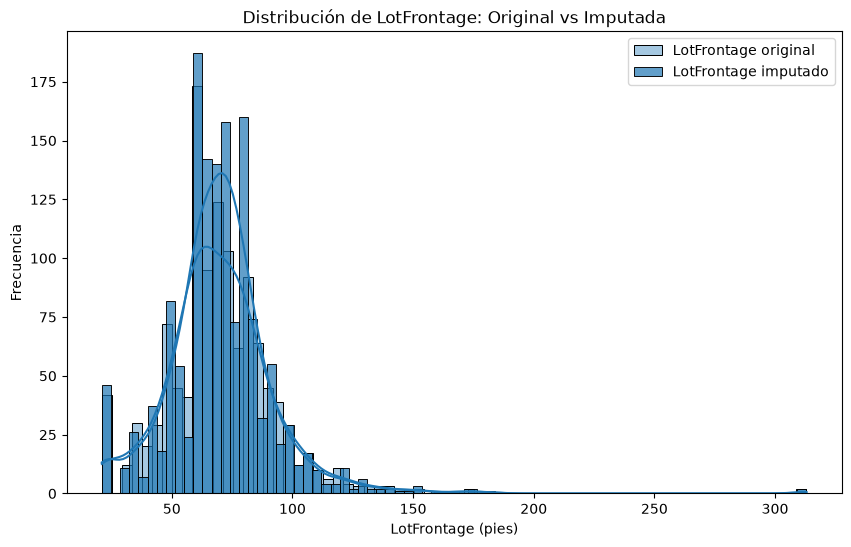

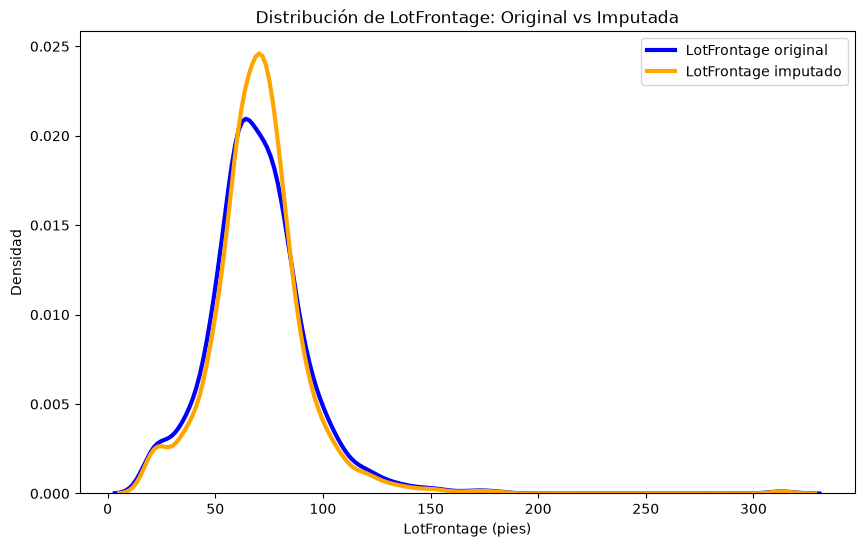

In [7]:
# --- Pregunta 3: Imputación agrupada de LotFrontage ---

# 1. Calcular la mediana de LotFrontage por Neighborhood
mediana_por_barrio = df.groupby('Neighborhood')['LotFrontage'].transform('median')

# 2. Crear una nueva columna en df_aumentado con los valores imputados
# Usar .fillna() para rellenar los valores nulos de LotFrontage con la mediana calculada por grupo
df_aumentado['LotFrontage_imputada'] =df_aumentado['LotFrontage'].fillna(mediana_por_barrio)

# 3. Verificar que ya no hay nulos en la nueva columna
# 3. Verificar que ya no hay nulos en la nueva columna
nulos_restantes = df_aumentado['LotFrontage_imputada'].isna().sum()
print(f"Nulos en LotFrontage original: {df['LotFrontage'].isna().sum()}")
print(f"Nulos en LotFrontage_imputada: {nulos_restantes}")
print("Todos los nulos fueron imputados" if nulos_restantes == 0 else f"Aún quedan {nulos_restantes} nulos.")

# 4. Comparar la distribución original vs imputada con un histograma
# Crear un histograma 
plt.figure(figsize=(10, 6))
sns.histplot(data=df_aumentado[['LotFrontage']],label='LotFrontage original',color='blue', alpha=0.4, kde=True,edgecolor='black')
sns.histplot(data=df_aumentado[['LotFrontage_imputada']],label='LotFrontage imputado',color='orange',alpha=0.7, kde=True,edgecolor='black')
plt.legend()
plt.title('Distribución de LotFrontage: Original vs Imputada')
plt.xlabel('LotFrontage (pies)')
plt.ylabel('Frecuencia')
plt.show()                  

# 4. Comparar distribuciones con curvas de densidad
plt.figure(figsize=(10, 6))

# Curva original (solo valores NO nulos)
sns.kdeplot(data=df_aumentado['LotFrontage'].dropna(), 
            label='LotFrontage original', 
            color='blue', 
            linewidth=3)

# Curva imputada
sns.kdeplot(data=df_aumentado['LotFrontage_imputada'], 
            label='LotFrontage imputado', 
            color='orange', 
            linewidth=3)

plt.legend()
plt.title('Distribución de LotFrontage: Original vs Imputada')
plt.xlabel('LotFrontage (pies)')
plt.ylabel('Densidad')
plt.show()

# 5. Interpretación: escribir en Markdown por qué la distribución imputada tiene picos en ciertos valores


### Interpretación de la pregunta 3
Como se ven en la graficas por densidad y el histograma la distribución de valores imputados (naranja) se ajustan a los valores reales (azul)
es decir la imputación mediante la mediana por barrio nos dice que es un buena aproximación para esos valores faltantes y tiene sentido
sentido en el contexto urbano, ya que las viviendas dentro de un mismo barrio suelen tener características de construcción homogéneas, incluyendo el frente del lote.
También en el histograma se puede ver que la mayoria de las casas tienen entre 50 y 100 pies de frente en esos metros se acumulan todas las frecuencias eso puede decirnos que estos datos tal vez solo contemplan barrios residenciales para clase media tendriamos que corroborarlos con datos urbanos de USA.

### Pregunta 4:
Ingeniería de características (Feature Engineering): Cree al menos cuatro
variables nuevas a partir de las existentes: TotalSF (suma de TotalBsmtSF,
1stFlrSF y 2ndFlrSF), HouseAge (YrSold − YearBuilt), RemodAge (YrSold −YearRemodAdd) y TotalBath (FullBath + 0.5·HalfBath + BsmtFullBath +
0.5·BsmtHalfBath). Muestre las primeras 5 filas de estas nuevas columnas
con df[[...]].head().

In [14]:
#Crear variables nuevas
#1.- Creando TotalSF,HouseAge,RemodAge,TotalBath
#Creando las variables nuevas

df_aumentado['TotalSF']=df_aumentado['TotalBsmtSF']+df_aumentado['1stFlrSF']+df_aumentado['2ndFlrSF']
df_aumentado['HouseAge']=df_aumentado['YrSold']-df_aumentado['YearBuilt']
df_aumentado['RemodAge']=df_aumentado['YrSold']-df_aumentado['YearRemodAdd']
df_aumentado['TotalBath']=df_aumentado['FullBath']+(.5*df_aumentado['HalfBath']+df_aumentado['BsmtFullBath']+.5*df_aumentado['BsmtHalfBath'])
#Se agrega los años verdaderos de antiguedad de la casa Edad de la casa hasta el dia de hoy
df_aumentado['HouseAgeTrue']=date.today().year-df_aumentado['YearBuilt']

#Agregando las nuevas descripciones

variable_description['TotalSF'] = "Suma de TotalBsmtSF + 1stFlrSF + 2ndFlrSF (pies cuadrados totales)"
variable_description['HouseAge'] = "Antigüedad de la casa en años desde el momento de la venta(YrSold - YearBuilt)"
variable_description['RemodAge'] = "Años desde la última remodelación (YrSold - YearRemodAdd)"
variable_description['TotalBath'] = "Número total de baños (completos + 0.5 por medio baño)"
variable_description['HouseAgeTrue'] = "Antigüedad de la casa desde el año actual ({año_actual} - YearBuilt)"

# Mostrar las primeras 5 filas de las nuevas columnas
print("Primeras 5 filas de las variables creadas:")
print("="*80)
df_aumentado[['TotalSF', 'HouseAge', 'RemodAge', 'TotalBath', 'HouseAgeTrue']].head()


Primeras 5 filas de las variables creadas:


,TotalSF,HouseAge,RemodAge,TotalBath,HouseAgeTrue
0,2566,5,5,3.5,23
1,2524,31,31,2.5,50
2,2706,7,6,3.5,25
3,2473,91,36,2.0,111
4,3343,8,8,3.5,26


**HouseAgeTrue (extra):** Edad de la casa desde el año actual (`2026 - YearBuilt`). Aporta una perspectiva diferente a `HouseAge`, permitiendo comparar ambas y elegir la más útil para el modelo.

### 5. Pipeline de preprocesamiento con validación cruzada:
Construya un Pipeline de scikit-learn que use ColumnTransformer para: (a)
imputar valores numéricos con la mediana y escalar con RobustScaler, (b)
imputar categóricos con la moda y aplicar One-Hot Encoding. Entrene un
modelo (Ridge o RandomForestRegressor) sobre SalePrice y evalúe su
desempeño con cross_val_score usando KFold (5 folds) y la métrica RMSE.
Reporte el RMSE promedio y su desviación estándar.


In [44]:
#Cargamos librerias
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

#1 pipeline de scikit-learn separar variables predictoras (X) de la variable objetivo (y)
print("="*80)
print("Pipeline de Scikit-learn")
print("Identificamos columnas, separamos la variables predictoras de la variable objetivo SalePrice")
X = df_aumentado.drop(columns=['SalePrice'])
y=df_aumentado['SalePrice']

print("Identificamos variables numéricas y categoricas")

columnas_numericas=X.select_dtypes(include=['int64','float64']).columns
columnas_categoricas=X.select_dtypes(include=['object','string']).columns

print(f"X tiene {X.shape[1]} variables predictoras y {X.shape[0]} registros.")
print(f"y tiene {y.shape[0]} valores de precio.")
print("="*80)
print(f"\nVariables numéricas ({len(columnas_numericas)}): {list(columnas_numericas)}")
print(f"\nVariables categóricas ({len(columnas_categoricas)}): {list(columnas_categoricas)}")


#a) imputar valores numéricos con la mediana y escalar con RobustScaler
transformador_numerico = Pipeline([
    ('imputador', SimpleImputer(strategy='median')),
    ('escalador', RobustScaler())
])

#b) imputar categóricos con la moda y aplicar One-Hot Encoding

transformador_categorico = Pipeline([
    ('imputador', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])


preprocesador = ColumnTransformer([
    ('numericas', transformador_numerico, columnas_numericas),
    ('categoricas', transformador_categorico, columnas_categoricas)
])
#Entrene un modelo (Ridge o RandomForestRegressor) sobre SalePrice y evalúe su desempeño con 
#cross_val_score usando KFold (5 folds) y la métrica RMSE. Reporte el RMSE promedio y su desviación estándar.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline_ridge = Pipeline([
    ('preprocesamiento', preprocesador), 
    ('modelo', Ridge(alpha=1.0))         
])

#Evaluar con cross_val_score
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
mse_scores = -cross_val_score(pipeline_ridge, X, y, cv=kfold, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(mse_scores)

# 7. Reportar resultados
print("="*80)
print("VALIDACIÓN CRUZADA CON RIDGE (5 FOLDS)")
print("DEscripción de la variable objetivo")
print(df_aumentado['SalePrice'].describe())
print("="*80)
print(f"✅ RMSE por fold: {[f'{rmse:.2f}' for rmse in rmse_scores]}")
print(f"✅ RMSE promedio: {rmse_scores.mean():.2f}")
print(f"✅ Desviación estándar: {rmse_scores.std():.2f}")
print("="*80)

Pipeline de Scikit-learn
Identificamos columnas, separamos la variables predictoras de la variable objetivo SalePrice
Identificamos variables numéricas y categoricas
X tiene 89 variables predictoras y 1460 registros.
y tiene 1460 valores de precio.

Variables numéricas (46): ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'LotFrontage_missing', 'MasVnrType_missing', 'FireplaceQu_missing', 'LotFrontage_imputada', 'TotalSF', 'HouseAge', 'RemodAge', 'TotalBath', 'HouseAgeTrue']

Variables categóricas (43): ['MSZoning', 'Street', 'Alley', 

### Interpretación de la Pregunta 5

El modelo Ridge evaluado con validación cruzada de 5 folds obtuvo un RMSE promedio de **33,566.80** con una desviación estándar de **10,392.40**.
El fold 3 tiene calificación mala es cas1 el 30% de la media de la variable objetivo 180,921,lo que sugiere que este subconjunto contiene propiedades con características atípicas o difíciles de predecir para un modelo lineal.
La alta desviación estándar (10,392) confirma que el modelo no es estable y su rendimiento depende en gran medida de los datos específicos con los que se entrena.

